In [1]:
import torch
from sorl.gat_sim import GAT, GATConfig, BOS_TOKEN_ID
torch.set_float32_matmul_precision('high')  # Enable TF32 for ~2x speedup
# For fast training, set 'BOS_TOKEN_ID' to 15 in 'sorl/gat_sim.py' 

gat_config = GATConfig(
    vocab_sizes=[BOS_TOKEN_ID+1, 6],  # 6 abstract tokens
    n_layer=4,
    n_head=4,
    n_embd=128,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

model = GAT(gat_config)
# model = model.to("cuda")
# model = torch.compile(model)

In [2]:
# ---- Copy & Paste Data Loader ----
from data.copy_paste import CopyPasteDataLoader

seq_len = 16
loader = CopyPasteDataLoader(vocab_size=16, max_token=10, seq_len=seq_len, device='cpu')
tokens, loss_mask = loader.get_batch(2)

(Exploration). Simplified Group Preference Optimization (SGPO) + Topological Similarity regularization
$$
\begin{align*}
&\mathcal{L}_{SGPO\,\,TOPO}(s, a_{i}) := \frac{\hat{p}_{\theta}(s | a_{i}) - \text{mean}(\hat{p}_{\theta}(s | a_{1:n}))}{\text{std}(\hat{p}_{\theta}(s | a_{1:n}))}\hat{p}_{\theta}(s | a) + \alpha \cdot \hat{p}_{\theta}(a | s) + \beta \cdot \mathcal{L}_{topo}(s, a_{1:n}) \\
&a_{i} \sim \hat{p}_{\theta}(a | s) \\
&\theta = \theta - {d\mathcal{L}_{SGPO}(s, a_{i})}/{d \theta} \quad \text{for } i \in \{1,2,\dots, n\}\\
\end{align*}
$$
Leads to emergent abstraction structure (unstable)

In [ ]:
from sorl.neo_utils import sorl_search_v4, compute_sgpo_loss_v2, sorl_evaluate_v2, compute_vocab_utilization_rate, compute_loss
from sorl.gapt import GatedPhaseTransition
import copy
from collections import defaultdict

# ------ SGPO + Topo regularization for emerging compositional abstraction structure -------
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)

batch_size = 16
memory_span = 2 * seq_len + 2
attn_blocksize = 1792
alpha_loss = 0.1
alpha_topo = 10.0
adv_mode = 0 # SGPO
topo_mode = 2 # covariance target 
util_dist_mode = 1 # stop grad on worse rollout
n = 2
min_temperature = 0.0
max_temperature = 5
temperatures = torch.tensor([min_temperature, max_temperature], device=model.device)
n_eval = 2 
temperatures_eval = torch.tensor([min_temperature, max_temperature], device=model.device)
K = 4
max_iterations = 2
num_steps = 500
gapt = GatedPhaseTransition()

record = defaultdict(list)
vocab_util = 1.0
for step in range(num_steps): 

    memory_span = 1792
 
    optimizer.zero_grad()

    tokens, _ = loader.get_batch(batch_size)

    # --- mixture of SoRL selection & deep supervision (avg. loss per iteration) ---
    with torch.no_grad(): 
        search_tokens, search_ppt, search_adv, abs_dist = sorl_search_v4(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures,
                                                                         mode=adv_mode, truncate_seq_len=False)
    # --- compute loss ---
    traj_loss, grpo_loss, topo_loss = compute_sgpo_loss_v2(search_tokens, search_adv, abs_dist, model, memory_span, attn_blocksize, topo_mode, util_dist_mode)    
                                       
    # loss = gapt.step(traj_loss, alpha_loss * abs_loss, verbose=True)
    loss = traj_loss + alpha_loss * grpo_loss + alpha_topo * topo_loss
    print("scaled topo loss: ", alpha_topo * topo_loss.item(), "traj loss: ", traj_loss.item())

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, max_temperature], device=model.device)
            val_tokens, val_adv, traj_loss, abs_loss, topo_sim = sorl_evaluate_v2(tokens, model, n=n_eval, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            traj_loss, abs_loss = compute_loss(val_tokens, model, memory_span=memory_span, attn_blocksize=attn_blocksize)
            vocab_util = compute_vocab_utilization_rate(val_tokens, model)
            record['vocab_util'].append(vocab_util * 100)
            record['search_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.item())
            record['alpha_loss'].append(alpha_loss)
            record['topo_sim'].append(topo_sim.item())
        print(f"validation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {vocab_util * 100:.2f}% | topo_sim: {topo_sim.item():.2f}")

scaled topo loss:  -0.0 traj loss:  3.295837163925171
validation step 0 | traj_loss: 3.26 | abs_loss: 3.31 | search adv: -0.01% | vocab util: 83.33% | topo_sim: 0.06
scaled topo loss:  -0.5187646299600601 traj loss:  3.2637059688568115
scaled topo loss:  0.0002622815554786939 traj loss:  3.2531020641326904
validation step 2 | traj_loss: 3.25 | abs_loss: 3.31 | search adv: -0.03% | vocab util: 66.67% | topo_sim: 0.09
scaled topo loss:  -0.5842552334070206 traj loss:  3.247305154800415
scaled topo loss:  -1.3085083663463593 traj loss:  3.243398904800415
validation step 4 | traj_loss: 3.23 | abs_loss: 3.28 | search adv: 0.24% | vocab util: 83.33% | topo_sim: 0.10
scaled topo loss:  -1.0470958054065704 traj loss:  3.239285469055176
scaled topo loss:  -1.1506304889917374 traj loss:  3.2270681858062744
validation step 6 | traj_loss: 3.22 | abs_loss: 3.24 | search adv: -0.18% | vocab util: 83.33% | topo_sim: 0.06
scaled topo loss:  -0.999738946557045 traj loss:  3.21144700050354
scaled topo l

In [ ]:
# all-rollout SoRL + topo mode 3 (covariance) + stop grad 
# --> traj loss 2.0 | vocab util: 33% | topo sim 0.01 | search adv: -2.1
# all rollout SoRL + topo mode 3 (covariance)
# -->

In [ ]:
# SGPO + Topo mode 0, weight 10.0: 
#    Observation: traj loss spikes up 15.73 in step 150 | search adv spikes down to -200% in step 150 | vocab util -> 33% and stabilize
#                 topo sim overall increase from 0.0 to 0.8~1.2 and fluctuates, abs_loss fluctuates 2.0 ~ 4.0, search advantages fluctuates -400% - -80%
# SGPO + Topo mode 0, weight 10.0: (second run)
#    Observation: traj loss fluctuates around 2.3, vocab collapse 16%, abs loss goes up then down to ~3.2, search adv goes nagative then back to ~0%
#                 topo sim goes up to 0.4 then down to 0.0, the 'chaotic phase' features a high traj loss, abs_loss, negative search_adv, high topo_sim behavior, 
#                 which aligns with our observation in the first run.  
# SGPO + Topo mode 0, weight 10.0 | stop grad on worse rollout in utility distance
#    Observation: traj loss fluctuates around 2.7  | search adv flucuates around -20% | vocab util 16%-33% 
#                 abs loss near 0.0 (fluctuates a bit), topo sim 0.01 - 0.10

# Conclusion: 
# - SGPO + topo reg (dot prod ver.)+ stop grad --> worse topo sim regularization, better traj loss, near collapse of vocab
#          search adv moderately negative. 

# SGPO + Topo mode 3, weight 10.0: 
#    Observation: traj loss fluctuates around 2.4, abs loss fluctuates 1.0 - 2.5, search adv fluctuates near 0% 
#                 topo sim goes up to 0.5 then down to near 0.0 
# SGPO + Topo mode 3, weight 10.0: 
#    Observation: traj loss fluctuates around 2.0, abs loss ~1.0, search adv goes positive ~10% but vocab collapse 16% 
#                 topo sim goes up to 0.80
# SGPO + Topo mode 3, weight 10.0 | stop grad on worse rollout in utility distance | topo regularization
#    Observation: traj loss drop to 1.16 (matching normal runs) | search adv oscillates -1200% - 10%, showing trend to further increment in oscillation range
#                 abs loss stabilizes <4. before step 150, then spikes up monotonically to 18 and beyond
#                 vocab util increase from 16% at the same time abs loss spikes up (step 150) then fluctuates around 33%
#                 topo sim increase from 0.0 to 0.13 - 0.20 (showing potential for further increment)

# Conclusion: 
# - stop gradient forbigs greedy utility degradation, increase 'specialziation' (big search adv magnitude)
#                 it also increase topological similarity, but it destabilizes greedy abstraction choice, when
#                 working together with SGPO. 
# --> SGPO + topo reg (corr. ver.) works better with stop grad trick (? traj loss is better, vcaob is nice, search adv is good, just the abs loss spiking up is a bit worrisome)


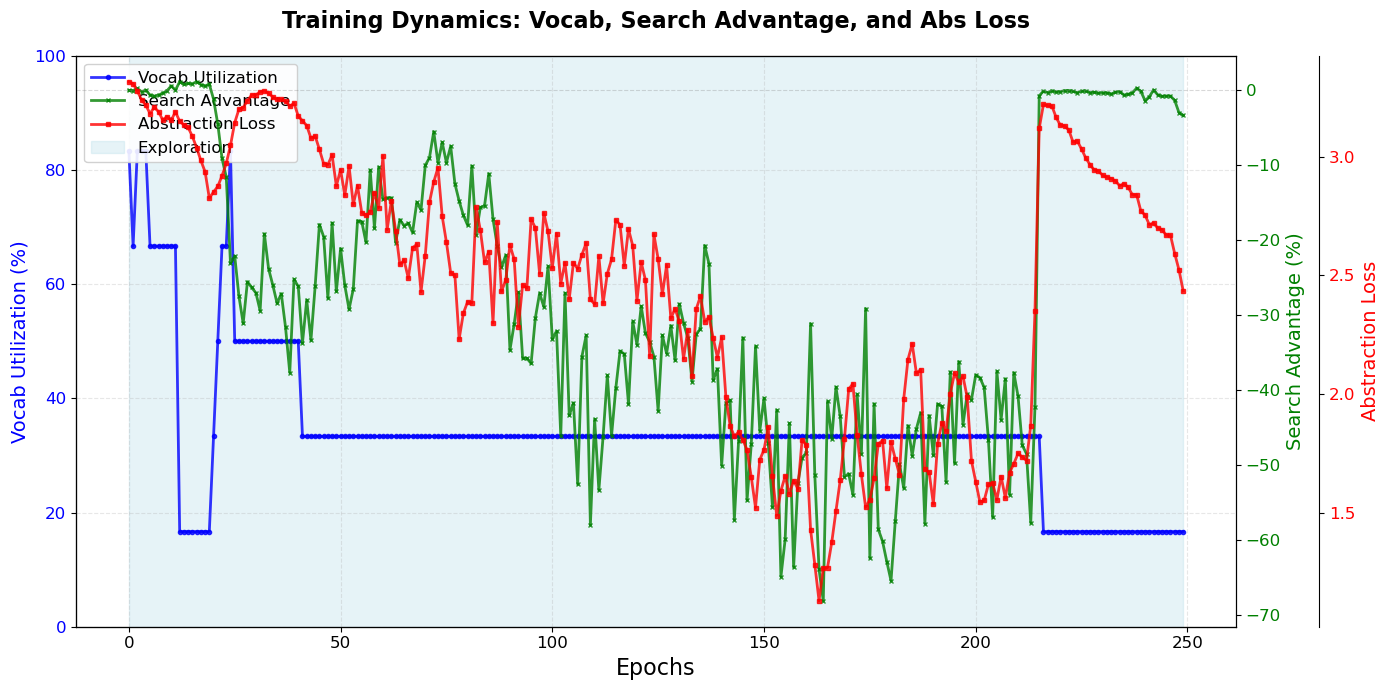

In [4]:
from sorl.stat import plot_training_metrics_combined

plot_training_metrics_combined(record)

In [6]:
# generate function implementation 
# ----------------------------------
from sorl.neo_utils import generate

tokens, loss_mask = loader.get_batch(1)
idx = tokens[:, :1 + seq_len].clone()
print(f"init   | idx: {idx[0].tolist()}")
for i in range(seq_len): 
    idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=torch.tensor(min_temperature))
    idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
    print(f"step {i+1} idx (abstraction free): {idx_without_abstraction.tolist()}")
    print(f"                         idx : {idx[0].tolist()}")

correct_cp = torch.allclose(idx_without_abstraction[1 : 1 + seq_len], idx_without_abstraction[1 + seq_len : 2 + 2*seq_len])
print(f"Copy correct: {correct_cp}")

init   | idx: [20, 0, 0, 5, 4, 6, 2, 9, 6, 4, 3, 9, 0, 8, 6, 7, 2]
step 1 idx (abstraction free): [20, 0, 0, 5, 4, 6, 2, 9, 6, 4, 3, 9, 0, 8, 6, 7, 2, 0]
                         idx : [20, 0, 0, 5, 4, 26, 6, 2, 9, 6, 26, 4, 3, 9, 0, 26, 8, 6, 7, 2, 26, 0]
step 2 idx (abstraction free): [20, 0, 0, 5, 4, 6, 2, 9, 6, 4, 3, 9, 0, 8, 6, 7, 2, 0, 0]
                         idx : [20, 0, 0, 5, 4, 26, 6, 2, 9, 6, 26, 4, 3, 9, 0, 26, 8, 6, 7, 2, 26, 0, 0]
step 3 idx (abstraction free): [20, 0, 0, 5, 4, 6, 2, 9, 6, 4, 3, 9, 0, 8, 6, 7, 2, 0, 0, 0]
                         idx : [20, 0, 0, 5, 4, 26, 6, 2, 9, 6, 26, 4, 3, 9, 0, 26, 8, 6, 7, 2, 26, 0, 0, 0]
step 4 idx (abstraction free): [20, 0, 0, 5, 4, 6, 2, 9, 6, 4, 3, 9, 0, 8, 6, 7, 2, 0, 0, 0, 4]
                         idx : [20, 0, 0, 5, 4, 26, 6, 2, 9, 6, 26, 4, 3, 9, 0, 26, 8, 6, 7, 2, 26, 0, 0, 0, 4]
step 5 idx (abstraction free): [20, 0, 0, 5, 4, 6, 2, 9, 6, 4, 3, 9, 0, 8, 6, 7, 2, 0, 0, 0, 4, 6]
                         idx : [20, 0,

In [21]:
from sorl.eval import compute_vocab_utilization_rate

def eval_cp(model, tokens, K, max_iterations, memory_span, seq_len, loader, temperature=torch.tensor(0.5), num_samples=100):
    n_correct = 0
    abs_idx = []
    for _ in range(num_samples): 
        tokens, loss_mask = loader.get_batch(1)
        idx = tokens[:, :1 + seq_len].clone()
        for i in range(seq_len): 
            idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=temperature)
            idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
            abs_idx.append(idx[idx >= model.vocab_sizes[0]])
        correct_cp = torch.allclose(idx_without_abstraction[1 : 1 + seq_len], idx_without_abstraction[1 + seq_len : 2 + 2*seq_len])
        n_correct += correct_cp
    acc = n_correct / num_samples
    print(f"=== Copy & Paste Evaluation ===\n Copy correct: {acc * 100:.2f}%")

    data = torch.cat(abs_idx, dim=0)
    abs_util_rate = compute_vocab_utilization_rate(data, model)
    return acc, abs_util_rate


eval_cp(model, tokens, K, max_iterations, memory_span, seq_len, loader, num_samples=20)

=== Copy & Paste Evaluation ===
 Copy correct: 100.00%


(1.0, 0.8333333333333334)

 Total abs tokens: 6 | Unique abs tokens: 1 | Abs util rate: 16.67%


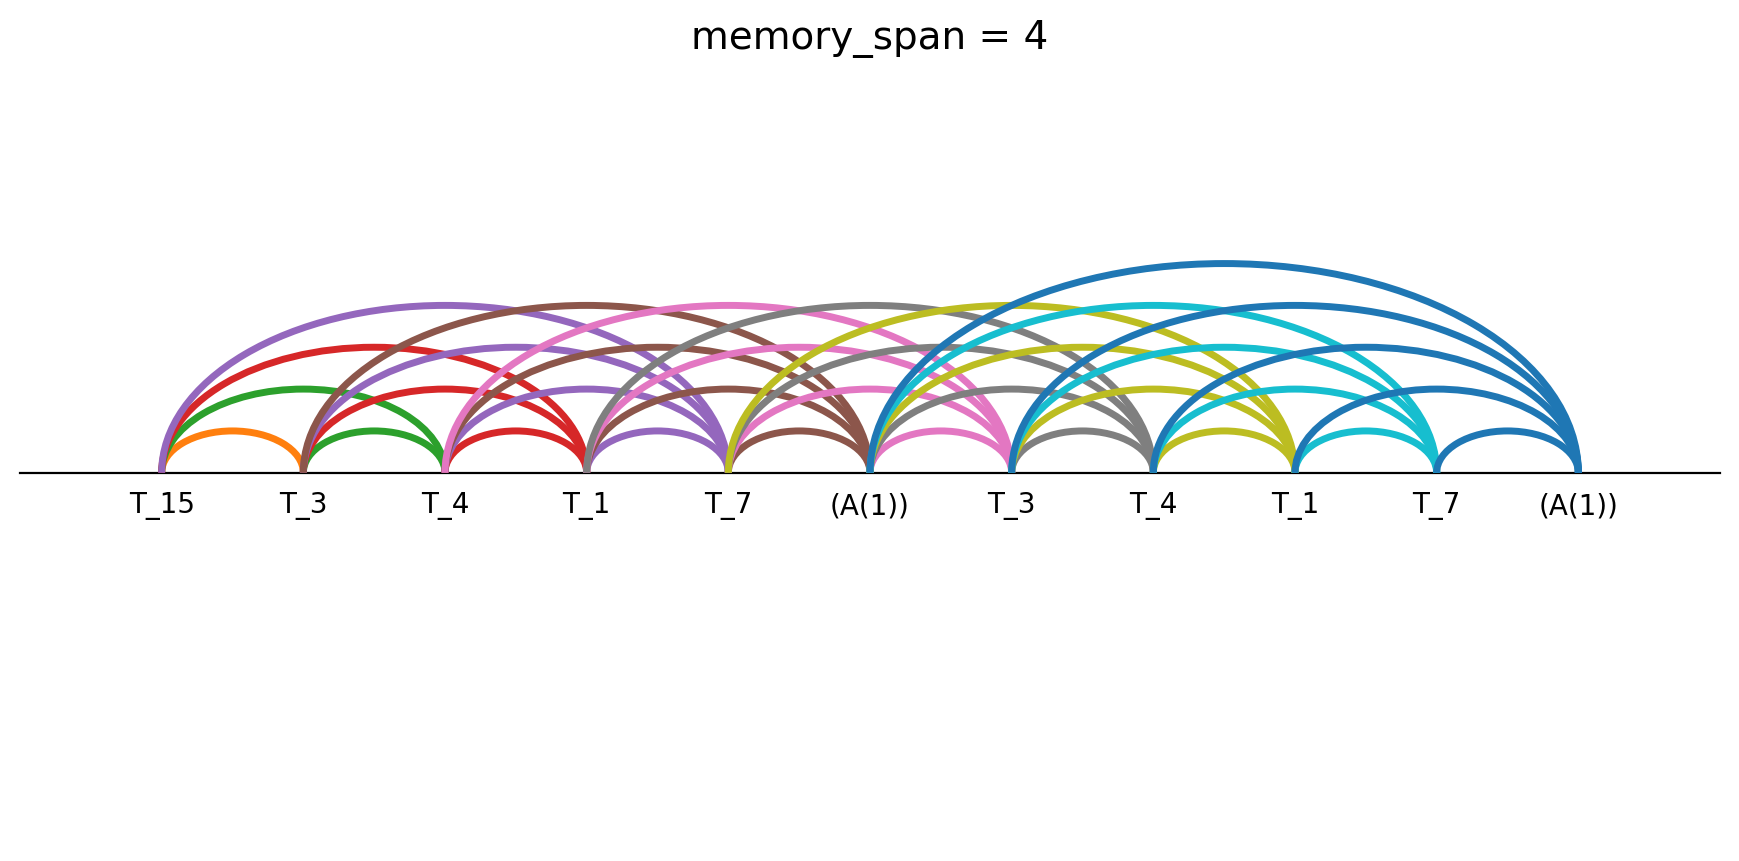

In [6]:
# Simple 2D Attention Mask (without num_heads dimension)
# ======================================================

import torch
from sorl.stat import plot_attn_arcs, materialize_attention_mask, AttentionMaskVisualizer

# Your existing variables
tokens, loss_mask = loader.get_batch(1)
with torch.no_grad(): 
    search_tokens, search_ppt, search_adv = sorl_search(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature,
                                                            truncate_seq_len=False)

# Generate 2D attention mask
levels = (search_tokens >= model.vocab_sizes[0]).long()
attn_mask = materialize_attention_mask(search_tokens, model, memory_span, attn_blocksize=1792)
visualizer = AttentionMaskVisualizer(search_tokens, model, attn_mask)

visualizer.plot_arcs(title=f"memory_span = {memory_span}")


In [4]:
# heuristic rollout
import os, glob, itertools
from pathlib import Path

# MPS specific data loader functional (single device ver.)
# --------------------------------------------
def _load_data_shard(file: Path):
    header = torch.from_file(str(file), False, 256, dtype=torch.int32) # header is 256 int32
    assert header[0] == 20240520, "magic number mismatch in the data .bin file"
    assert header[1] == 1, "unsupported version"
    num_tokens = int(header[2]) # number of tokens (claimed)
    with file.open("rb", buffering=0) as f:
        tokens = torch.empty(num_tokens, dtype=torch.uint16, pin_memory=False) # MPS requires pin_memory=False
        f.seek(256 * 4)
        nbytes = f.readinto(tokens.numpy()) # avoid bytes->array copy by @YouJiacheng
        assert nbytes == 2 * num_tokens, "number of tokens read does not match header"
    return tokens

def data_generator(filename_pattern: str, sequence_length: int, device: str): 

    filename_pattern = "data/fineweb10B/fineweb_train_*.bin"
    files = [Path(file) for file in sorted(glob.glob(filename_pattern))]
    file_iter = itertools.cycle(files)
    tokens, pos = _load_data_shard(next(file_iter)), 0
    while True: 
        # Concern 1. Doesn't this means end-of-file is never reached?
        if pos + sequence_length + 1 >= len(tokens): # not enough data left -> load a new file
            tokens, pos = _load_data_shard(next(file_iter)), 0

        idx = tokens[pos : pos + sequence_length + 1].unsqueeze(0).to(device=device, dtype=torch.int32, non_blocking=True)
        pos += sequence_length
        yield idx


data = _load_data_shard(Path("data/fineweb10B/fineweb_train_000002.bin"))

train_loader = data_generator(filename_pattern="data/fineweb10B/fineweb_train_*.bin", sequence_length=256, device="cpu")
val_loader = data_generator(filename_pattern="data/fineweb10B/fineweb_val_000000.bin", sequence_length=256, device="cpu")

In [ ]:
from sorl.neo_utils import sorl_search_v2 

n = 2
K = 8
max_iterations=2
memory_span=1792
attn_blocksize=1792
temperature=10.0 

tokens = next(train_loader)

with torch.no_grad(): 
    search_tokens, search_ppt, search_adv, pt_curiosity = sorl_search_v2(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature)

In [ ]:
# --- Benchmark Speed & Memory Cost --- 
from sorl.benchmark import run_benchmark_suite
from sorl.neo_utils import sorl_search_v4
import torch 


# Levenshtein distance computation might've grabbed the majority of time
# --- it's current speed is un-acceptable. 